# Assessing Model Results


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
import moviepy.video.io.ImageSequenceClip

In [2]:
run_dir = "F:/CS185C_DATA/model/diags"

In [3]:
# define the parameters that will be used in the data file
delX = 1/12
delY = 1/14
xgOrigin = 78
ygOrigin = 0
n_rows = 360
n_cols = 260

# recreate the grids that will be used in the model
xc = np.arange(xgOrigin+delX/2, xgOrigin+n_cols*delX, delX)
yc = np.arange(ygOrigin+delY/2, ygOrigin+n_rows*delY+delY/2, delY)
XC, YC = np.meshgrid(xc, yc)

# Sea Surface Temperature
To assess my model, I will start with looking at the THETA field of the first output of TS_surf_daily_mean. 

In [4]:
grid = np.fromfile(os.path.join(run_dir,'TS_surf_daily_mean',
                                'TS_surf_daily_mean.0000000288.data'), '>f4')
grid = grid.reshape((2,n_rows,n_cols))

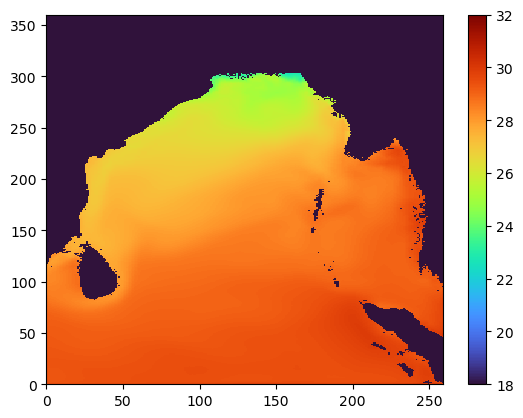

In [5]:
C = plt.pcolormesh(grid[0,:,:-1], cmap='turbo', vmin=18,vmax=32)
plt.colorbar(C)
plt.show()

# Making a Timeseries
Our results look good. Now lets make a timeseries for a point near the coast of India

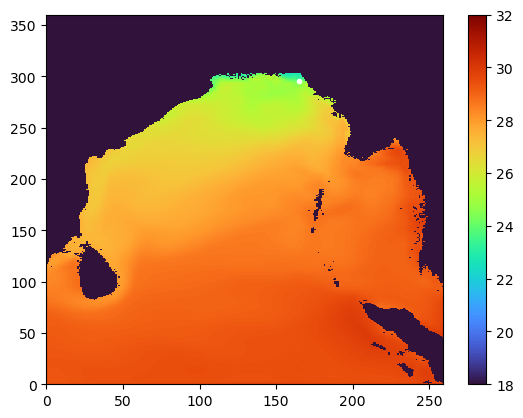

In [6]:
row = 295
col = 165
C = plt.pcolormesh(grid[0,:,:-1], cmap='turbo', vmin=18,vmax=32)
plt.plot(col,row,'w.')
plt.colorbar(C)
plt.show()

In [7]:
timestep_numbers = []
theta_values = []
for file_name in sorted(os.listdir(os.path.join(run_dir,'TS_surf_daily_mean'))):
    if file_name[-4:]=='data':
        # get the timestep number
        timestep_numbers.append(int(file_name.split('.')[-2]))

        grid = np.fromfile(os.path.join(run_dir,'TS_surf_daily_mean',
                                file_name), '>f4')
        grid = grid.reshape((2,n_rows,n_cols))
        theta_values.append(grid[0,row,col])

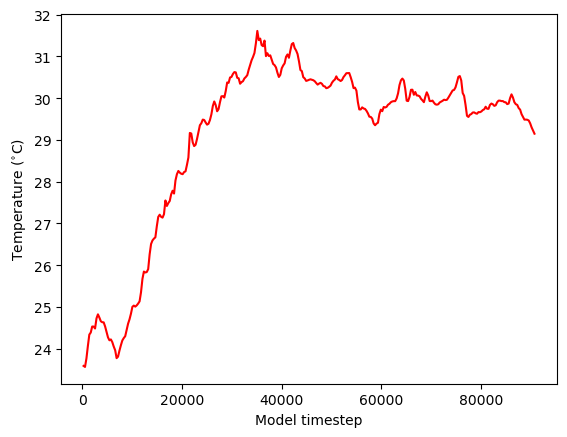

In [8]:
plt.plot(timestep_numbers, theta_values,'r-')
plt.ylabel('Temperature ($^{\circ}$C)')
plt.xlabel('Model timestep')
plt.show()

Timeseries plot looks good. Now lets make a movie to see how our model progresses over time

# Making a Movie for Sea Surface Temperature

In [9]:
plot_dir = "F:/CS185C_DATA/plots2"

In [10]:
def plot_panel(run_dir, plot_dir, file_name):

    # read in the data
    grid = np.fromfile(os.path.join(run_dir,'TS_surf_daily_mean',
                                file_name), '>f4')
    grid = grid.reshape((2,n_rows,n_cols))
    timestep_number = int(file_name.split('.')[-2])

    # make a figure 
    fig = plt.figure(figsize=(7,8))
    gs1 = GridSpec(11, 10, left=0.1, right=0.98, bottom=0.06, top=0.95, hspace=0.05)

    # plot the temperature
    ax1 = fig.add_subplot(gs1[:-2, :])
    C = ax1.pcolormesh(XC[:,:-1], YC[:,:-1], grid[0,:,:-1], cmap='turbo', vmin=18,vmax=32)
    plt.colorbar(C, label='Temperature ($^{\circ}$C)')

    # # plot the land in grey
    # land = (grid[0,:,:-1]==0).astype(int)
    # print(np.min(land), np.max(land))
    # land = np.ma.masked_where(land, land==0)
    # print(land)
    # ax1.pcolormesh(XC[:,:-1], YC[:,:-1], land, cmap='Greys')#, vmin=-1, vmax=1)
    
    # format the axes
    plt.title('Bay of Bengal Current')
    plt.ylabel('Latitude')
    plt.xlabel('Longitude')

    max_timestep_number = int(366*24*60*60/300)
    ax2 = fig.add_subplot(gs1[-1, :-2])
    rect = Rectangle((0,0),timestep_number, 1, facecolor='grey', edgecolor='k')
    ax2.add_patch(rect)
    ax2.set_xlim([0, max_timestep_number])
    ax2.set_ylim([0, 1])
    ax2.set_xticks([0,max_timestep_number])
    ax2.set_xticklabels([2010, 2011])
    ax2.set_yticklabels([])
    ax2.set_xlabel('Time')
    
    output_file = os.path.join(plot_dir,'panels',file_name[:-5]+'.png')
    plt.savefig(output_file, facecolor='white')
    plt.close(fig)


# test the function
plot_panel(run_dir, plot_dir, 'TS_surf_daily_mean.0000000288.data')
plot_panel(run_dir, plot_dir, 'TS_surf_daily_mean.0000000576.data')

In [11]:
for file_name in sorted(os.listdir(os.path.join(run_dir,'TS_surf_daily_mean'))):
    if file_name[-4:]=='data':
        plot_panel(run_dir, plot_dir, file_name)

In [12]:
panel_list = []
for file_name in sorted(os.listdir(os.path.join(plot_dir,'panels'))):
    if file_name[-4:]=='.png':
        panel_list.append(os.path.join(plot_dir,'panels',file_name))

In [13]:
# set the frames per second
fps=5

# use the ImageSequenceClip module to set up the clip
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(panel_list, fps=fps)

# write the video to a file
clip.write_videofile(os.path.join(plot_dir,'Bay of Bengal Sea Surface Temperature.mp4'))

Moviepy - Building video F:/CS185C_DATA/plots2\Bay of Bengal Sea Surface Temperature.mp4.
Moviepy - Writing video F:/CS185C_DATA/plots2\Bay of Bengal Sea Surface Temperature.mp4



Moviepy - Done !
Moviepy - video ready F:/CS185C_DATA/plots2\Bay of Bengal Sea Surface Temperature.mp4


Now lets repeat the same steps for the following fields of interest, sea surface height, zonal and meridonal velocity

# Sea Surface Height

In [14]:
grid_monsoon_height = np.fromfile(os.path.join(run_dir,
                                     'EtaN_day_snap',
                                     'EtaN_day_snap.0000017424.data'), '>f4')
grid_monsoon_height = grid_monsoon_height.reshape((n_rows,n_cols))

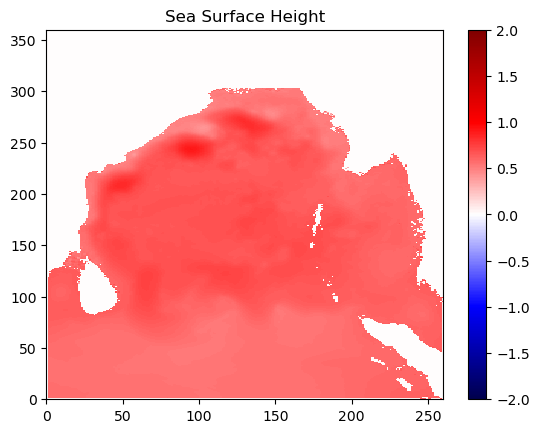

In [15]:
C = plt.pcolormesh(grid_monsoon_height,
                   cmap='seismic',vmin=-2, vmax=2)
plt.colorbar(C)
plt.title('Sea Surface Height')
plt.show()

# Making a Timeseries
Our results look good. Now lets make a timeseries for a point near the coast of India using the same point

In [16]:
row = 295
col = 165

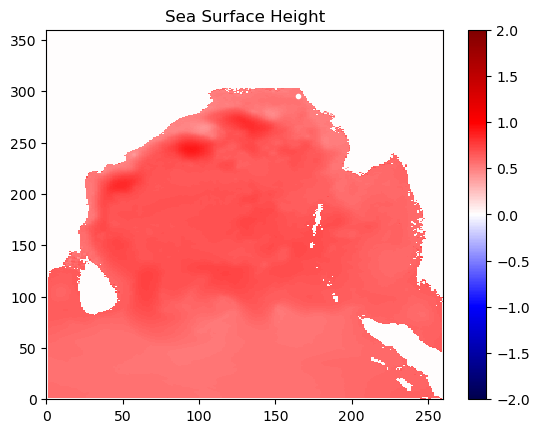

In [17]:
C = plt.pcolormesh(grid_monsoon_height,
                   cmap='seismic',vmin=-2, vmax=2)
plt.colorbar(C)
plt.plot(col,row,'w.')
plt.title('Sea Surface Height')
plt.show()

In [18]:
timestep_numbers = []
etan_values = []
for file_name in sorted(os.listdir(os.path.join(run_dir,'EtaN_day_snap'))):
    if file_name[-4:]=='data':
        # get the timestep number
        timestep_numbers.append(int(file_name.split('.')[-2]))

        grid = np.fromfile(os.path.join(run_dir,'EtaN_day_snap',
                                file_name), '>f4')
        grid = grid.reshape((n_rows,n_cols))
        etan_values.append(grid[row,col])

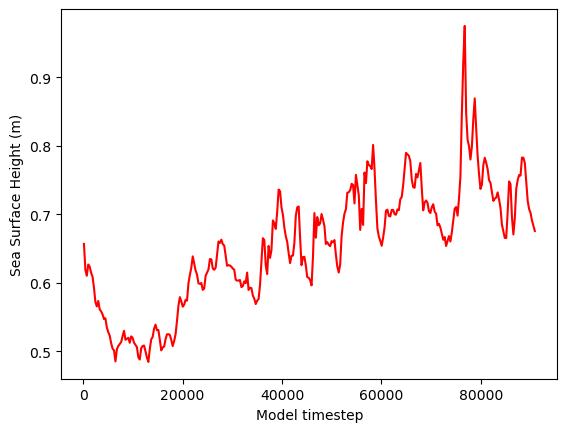

In [19]:
plt.plot(timestep_numbers, etan_values,'r-')
plt.ylabel('Sea Surface Height (m)')
plt.xlabel('Model timestep')
plt.show()

# Making a Movie for Sea Surface Height

In [20]:
plot_dir = "F:/CS185C_DATA/plot3"

In [21]:
def plot_panel(run_dir, plot_dir, file_name):

    # read in the data
    grid = np.fromfile(os.path.join(run_dir,'EtaN_day_snap',
                                file_name), '>f4')
    grid = grid.reshape((n_rows,n_cols))
    timestep_number = int(file_name.split('.')[-2])

    # make a figure 
    fig = plt.figure(figsize=(7,8))
    gs1 = GridSpec(11, 10, left=0.1, right=0.98, bottom=0.06, top=0.95, hspace=0.05)

    # plot the SSH
    ax1 = fig.add_subplot(gs1[:-2, :])
    C = ax1.pcolormesh(XC[:,:-1], YC[:,:-1], grid[:,:-1], cmap='turbo',vmin=-1, vmax=1.5)
    plt.colorbar(C, label='Sea Surface Height (m)')

    # # plot the land in grey
    # land = (grid[0,:,:-1]==0).astype(int)
    # print(np.min(land), np.max(land))
    # land = np.ma.masked_where(land, land==0)
    # print(land)
    # ax1.pcolormesh(XC[:,:-1], YC[:,:-1], land, cmap='Greys')#, vmin=-1, vmax=1)
    
    # format the axes
    plt.title('Bay of Bengal SSH')
    plt.ylabel('Latitude')
    plt.xlabel('Longitude')

    max_timestep_number = int(366*24*60*60/300)
    ax2 = fig.add_subplot(gs1[-1, :-2])
    rect = Rectangle((0,0),timestep_number, 1, facecolor='grey', edgecolor='k')
    ax2.add_patch(rect)
    ax2.set_xlim([0, max_timestep_number])
    ax2.set_ylim([0, 1])
    ax2.set_xticks([0,max_timestep_number])
    ax2.set_xticklabels([2010, 2011])
    ax2.set_yticklabels([])
    ax2.set_xlabel('Time')
    
    output_file = os.path.join(plot_dir,'panels',file_name[:-5]+'.png')
    plt.savefig(output_file, facecolor='white')
    plt.close(fig)


# test the function
plot_panel(run_dir, plot_dir, 'EtaN_day_snap.0000000144.data')
plot_panel(run_dir, plot_dir, 'EtaN_day_snap.0000000432.data')

In [22]:
for file_name in sorted(os.listdir(os.path.join(run_dir,'EtaN_day_snap'))):
    if file_name[-4:]=='data':
        plot_panel(run_dir, plot_dir, file_name)

In [23]:
panel_list = []
for file_name in sorted(os.listdir(os.path.join(plot_dir,'panels'))):
    if file_name[-4:]=='.png':
        panel_list.append(os.path.join(plot_dir,'panels',file_name))

In [24]:
# set the frames per second
fps=5

# use the ImageSequenceClip module to set up the clip
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(panel_list, fps=fps)

# write the video to a file
clip.write_videofile(os.path.join(plot_dir,'Bay of Bengal Sea Surface Height.mp4'))

Moviepy - Building video F:/CS185C_DATA/plot3\Bay of Bengal Sea Surface Height.mp4.
Moviepy - Writing video F:/CS185C_DATA/plot3\Bay of Bengal Sea Surface Height.mp4



Moviepy - Done !
Moviepy - video ready F:/CS185C_DATA/plot3\Bay of Bengal Sea Surface Height.mp4


# Zonal Velocity
For this field of interest, we will be looking at velocity at the sea surface level 

In [26]:
grid_monsoon_vel = np.fromfile(os.path.join(run_dir,
                                     'vel_3D_mon_snap',
                                     'vel_3D_mon_snap.0000026208.data'), '>f4')
grid_monsoon_vel = grid_monsoon_vel.reshape((2,50,n_rows,n_cols))

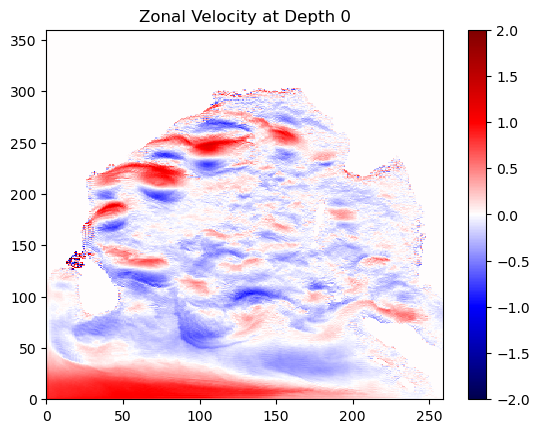

In [27]:
C = plt.pcolormesh(grid_monsoon_vel[0,0,:,:-1],
                   cmap='seismic',vmin=-2, vmax=2)
plt.colorbar(C)
plt.title('Zonal Velocity at Depth 0')
plt.show()

# Making a timeseries

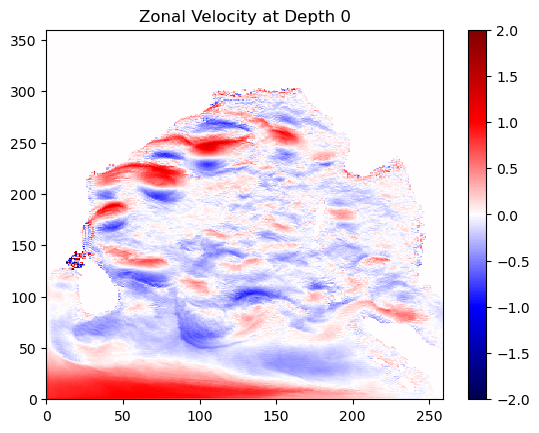

In [28]:
row = 295
col = 165

C = plt.pcolormesh(grid_monsoon_vel[0,0,:,:-1],
                   cmap='seismic',vmin=-2, vmax=2)
plt.colorbar(C)
plt.plot(col,row,'w.')
plt.title('Zonal Velocity at Depth 0')
plt.show()

In [29]:
timestep_numbers = []
vel_values = []
for file_name in sorted(os.listdir(os.path.join(run_dir,'vel_3D_mon_snap'))):
    if file_name[-4:]=='data':
        # get the timestep number
        timestep_numbers.append(int(file_name.split('.')[-2]))

        grid = np.fromfile(os.path.join(run_dir,'vel_3D_mon_snap',
                                file_name), '>f4')
        grid = grid.reshape((2,50,n_rows,n_cols))
        vel_values.append(grid[0,0,row,col])

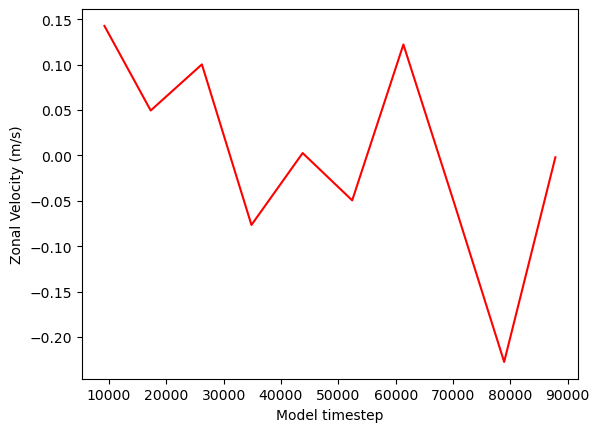

In [30]:
plt.plot(timestep_numbers, vel_values,'r-')
plt.ylabel('Zonal Velocity (m/s)')
plt.xlabel('Model timestep')
plt.show()

# Making a Movie for Zonal Velocity at Depth 0

In [31]:
plot_dir = "F:/CS185C_DATA/plot4"

In [32]:
def plot_panel(run_dir, plot_dir, file_name):

    # read in the data
    grid = np.fromfile(os.path.join(run_dir,'vel_3D_mon_snap',
                                file_name), '>f4')
    grid = grid.reshape((2,50,n_rows,n_cols))
    timestep_number = int(file_name.split('.')[-2])

    # make a figure 
    fig = plt.figure(figsize=(7,8))
    gs1 = GridSpec(11, 10, left=0.1, right=0.98, bottom=0.06, top=0.95, hspace=0.05)

    # plot the SSH
    ax1 = fig.add_subplot(gs1[:-2, :])
    C = ax1.pcolormesh(XC[:,:-1], YC[:,:-1], grid[0,0,:,:-1], cmap='seismic',vmin=-1.5, vmax=1.5)
    plt.colorbar(C, label='Velocity (m/s)')

    # # plot the land in grey
    # land = (grid[0,:,:-1]==0).astype(int)
    # print(np.min(land), np.max(land))
    # land = np.ma.masked_where(land, land==0)
    # print(land)
    # ax1.pcolormesh(XC[:,:-1], YC[:,:-1], land, cmap='Greys')#, vmin=-1, vmax=1)
    
    # format the axes
    plt.title('Zonal Velocity at Depth 0')
    plt.ylabel('Latitude')
    plt.xlabel('Longitude')

    max_timestep_number = int(366*24*60*60/300)
    ax2 = fig.add_subplot(gs1[-1, :-2])
    rect = Rectangle((0,0),timestep_number, 1, facecolor='grey', edgecolor='k')
    ax2.add_patch(rect)
    ax2.set_xlim([0, max_timestep_number])
    ax2.set_ylim([0, 1])
    ax2.set_xticks([0,max_timestep_number])
    ax2.set_xticklabels([2010, 2011])
    ax2.set_yticklabels([])
    ax2.set_xlabel('Time')
    
    output_file = os.path.join(plot_dir,'panels',file_name[:-5]+'.png')
    plt.savefig(output_file, facecolor='white')
    plt.close(fig)


# test the function
plot_panel(run_dir, plot_dir, 'vel_3D_mon_snap.0000009216.data')

In [33]:
for file_name in sorted(os.listdir(os.path.join(run_dir,'vel_3D_mon_snap'))):
    if file_name[-4:]=='data':
        plot_panel(run_dir, plot_dir, file_name)

In [34]:
panel_list = []
for file_name in sorted(os.listdir(os.path.join(plot_dir,'panels'))):
    if file_name[-4:]=='.png':
        panel_list.append(os.path.join(plot_dir,'panels',file_name))

In [35]:
# set the frames per second
fps=5

# use the ImageSequenceClip module to set up the clip
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(panel_list, fps=fps)

# write the video to a file
clip.write_videofile(os.path.join(plot_dir,'Zonal Velocity at Depth 0.mp4'))

Moviepy - Building video F:/CS185C_DATA/plot4\Zonal Velocity at Depth 0.mp4.
Moviepy - Writing video F:/CS185C_DATA/plot4\Zonal Velocity at Depth 0.mp4



Moviepy - Done !
Moviepy - video ready F:/CS185C_DATA/plot4\Zonal Velocity at Depth 0.mp4


# Meridional Velocity
With zonal velocity alike, we will be looking at meridional velocity at the surface level (Depth 0)

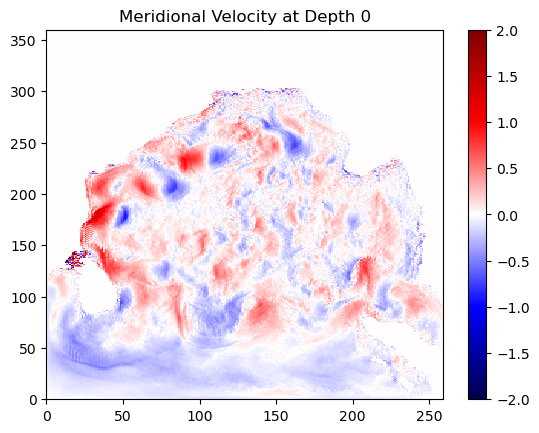

In [45]:
C = plt.pcolormesh(grid_monsoon_vel[1,0,:,:-1],
                   cmap='seismic',vmin=-2, vmax=2)
plt.colorbar(C)
plt.title('Meridional Velocity at Depth 0')
plt.show()

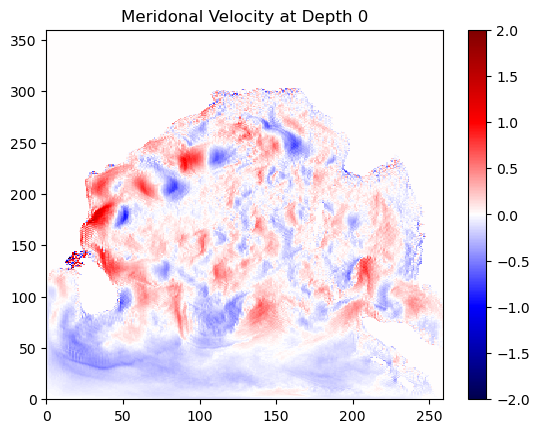

In [37]:
row = 295
col = 165

C = plt.pcolormesh(grid_monsoon_vel[1,0,:,:-1],
                   cmap='seismic',vmin=-2, vmax=2)
plt.colorbar(C)
plt.plot(col,row,'w.')
plt.title('Meridonal Velocity at Depth 0')
plt.show()

In [38]:
timestep_numbers = []
vel_values = []
for file_name in sorted(os.listdir(os.path.join(run_dir,'vel_3D_mon_snap'))):
    if file_name[-4:]=='data':
        # get the timestep number
        timestep_numbers.append(int(file_name.split('.')[-2]))

        grid = np.fromfile(os.path.join(run_dir,'vel_3D_mon_snap',
                                file_name), '>f4')
        grid = grid.reshape((2,50,n_rows,n_cols))
        vel_values.append(grid[1,0,row,col])

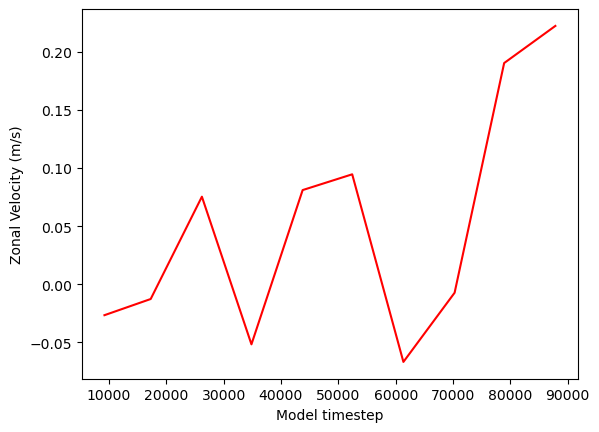

In [39]:
plt.plot(timestep_numbers, vel_values,'r-')
plt.ylabel('Zonal Velocity (m/s)')
plt.xlabel('Model timestep')
plt.show()

# Making a Movie for Meridional Velocity at Depth 0

In [40]:
plot_dir = "F:/CS185C_DATA/plot5"

In [41]:
def plot_panel(run_dir, plot_dir, file_name):

    # read in the data
    grid = np.fromfile(os.path.join(run_dir,'vel_3D_mon_snap',
                                file_name), '>f4')
    grid = grid.reshape((2,50,n_rows,n_cols))
    timestep_number = int(file_name.split('.')[-2])

    # make a figure 
    fig = plt.figure(figsize=(7,8))
    gs1 = GridSpec(11, 10, left=0.1, right=0.98, bottom=0.06, top=0.95, hspace=0.05)

    # plot the SSH
    ax1 = fig.add_subplot(gs1[:-2, :])
    C = ax1.pcolormesh(XC[:,:-1], YC[:,:-1], grid[1,0,:,:-1], cmap='seismic',vmin=-1.5, vmax=1.5)
    plt.colorbar(C, label='Velocity (m/s)')

    # # plot the land in grey
    # land = (grid[0,:,:-1]==0).astype(int)
    # print(np.min(land), np.max(land))
    # land = np.ma.masked_where(land, land==0)
    # print(land)
    # ax1.pcolormesh(XC[:,:-1], YC[:,:-1], land, cmap='Greys')#, vmin=-1, vmax=1)
    
    # format the axes
    plt.title('Meridonal Velocity at Depth 0')
    plt.ylabel('Latitude')
    plt.xlabel('Longitude')

    max_timestep_number = int(366*24*60*60/300)
    ax2 = fig.add_subplot(gs1[-1, :-2])
    rect = Rectangle((0,0),timestep_number, 1, facecolor='grey', edgecolor='k')
    ax2.add_patch(rect)
    ax2.set_xlim([0, max_timestep_number])
    ax2.set_ylim([0, 1])
    ax2.set_xticks([0,max_timestep_number])
    ax2.set_xticklabels([2010, 2011])
    ax2.set_yticklabels([])
    ax2.set_xlabel('Time')
    
    output_file = os.path.join(plot_dir,'panels',file_name[:-5]+'.png')
    plt.savefig(output_file, facecolor='white')
    plt.close(fig)


# test the function
plot_panel(run_dir, plot_dir, 'vel_3D_mon_snap.0000009216.data')

In [42]:
for file_name in sorted(os.listdir(os.path.join(run_dir,'vel_3D_mon_snap'))):
    if file_name[-4:]=='data':
        plot_panel(run_dir, plot_dir, file_name)

In [43]:
panel_list = []
for file_name in sorted(os.listdir(os.path.join(plot_dir,'panels'))):
    if file_name[-4:]=='.png':
        panel_list.append(os.path.join(plot_dir,'panels',file_name))

In [44]:
# set the frames per second
fps=5

# use the ImageSequenceClip module to set up the clip
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(panel_list, fps=fps)

# write the video to a file
clip.write_videofile(os.path.join(plot_dir,'Meridonal Velocity at Depth 0.mp4'))

Moviepy - Building video F:/CS185C_DATA/plot5\Meridonal Velocity at Depth 0.mp4.
Moviepy - Writing video F:/CS185C_DATA/plot5\Meridonal Velocity at Depth 0.mp4



Moviepy - Done !
Moviepy - video ready F:/CS185C_DATA/plot5\Meridonal Velocity at Depth 0.mp4


Our model results look good, we will proceed with answering the science question in another notebook